In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
def plot_digits(data, title, n_to_show=10):
    """Helper function to plot the first 'n' digits."""
    plt.figure(figsize=(10, 2))
    plt.suptitle(title, fontsize=16)
    for i in range(n_to_show):
        ax = plt.subplot(1, n_to_show, i + 1)
        # Reshape to 8x8 for plotting
        ax.imshow(data[i].reshape(8, 8), cmap='gray_r')
        ax.axis('off')
    plt.show()

def plot_embedding(X_2D, y, title=None):
    """Helper function to plot 2D embeddings."""
    plt.figure(figsize=(10, 8))
    labels = np.unique(y)
    cmap = plt.cm.get_cmap("jet", len(labels))

    for i, label in enumerate(labels):
        indices = (y == label)
        plt.scatter(X_2D[indices, 0], X_2D[indices, 1], 
                    c=[cmap(i)], label=str(label), s=15, alpha=0.7)

    plt.legend(loc='best', markerscale=2., title="Digit")
    if title:
        plt.title(title, fontsize=16)
    plt.show()

Loaded dataset with shape: (1797, 64)


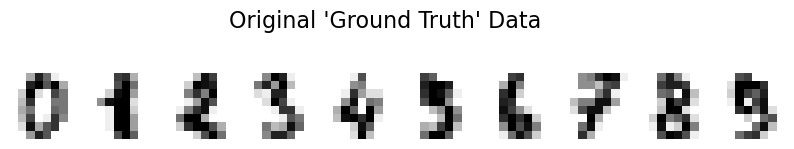

In [3]:
# Load the digits dataset
digits = datasets.load_digits(n_class=10)
X_full = digits.data
y = digits.target

n_samples, n_features = X_full.shape
print(f"Loaded dataset with shape: {X_full.shape}")

# --- IMPORTANT ---
# Standardize the data. PCA/PPCA works on covariance.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Plot the original (unscaled) data to see what it looks like
plot_digits(X_full, "Original 'Ground Truth' Data")

In [4]:
class PPCA_from_scratch:
    """
    Implements PPCA using the closed-form Maximum Likelihood solution.
    (Tipping and Bishop, 1999)
    """
    def __init__(self, n_components):
        self.k = n_components  # Number of latent dimensions (k)
        self.W = None          # The (features x k) projection matrix
        self.mu = None         # The (features,) data mean
        self.sigma2 = None     # The (scalar) variance
        
        # Helper matrices for fast transforms
        self.M = None
        self.M_inv = None

    def fit(self, X):
        """
        Fits the model parameters (W, mu, sigma2) to the data X.
        """
        n, d = X.shape  # n_samples, n_features (d)
        
        # 1. Calculate the data mean
        self.mu = X.mean(axis=0)
        
        # 2. Calculate the data covariance matrix (d x d)
        C = np.cov(X, rowvar=False)
        
        # 3. Find eigenvalues/eigenvectors of the covariance matrix
        eig_vals, eig_vecs = np.linalg.eigh(C)
        
        # 4. Sort eigenvalues/vectors in descending order
        idx = np.argsort(eig_vals)[::-1]
        eig_vals = eig_vals[idx]
        eig_vecs = eig_vecs[:, idx]
        
        # 5. Get top k eigenvalues (L_k) and eigenvectors (U_k)
        L_k = np.diag(eig_vals[:self.k])
        U_k = eig_vecs[:, :self.k]
        
        # 6. Calculate sigma2 (the ML estimate)
        # It's the average of the *discarded* eigenvalues
        self.sigma2 = np.mean(eig_vals[self.k:])
        
        # 7. Calculate W (the ML estimate)
        # W = U_k * (L_k - sigma2*I)^(1/2)
        # Note: We use np.diag(L_k) - self.sigma2 to subtract the scalar
        self.W = U_k @ np.sqrt(L_k - self.sigma2 * np.eye(self.k))
        
        # 8. Pre-calculate M for fast transforms
        # M = W.T @ W + sigma2*I
        self.M = self.W.T @ self.W + self.sigma2 * np.eye(self.k)
        self.M_inv = np.linalg.inv(self.M)
        
    def transform(self, X):
        """
        Projects high-dimensional data X into the latent space Z.
        Z = (X - mu) @ W @ M_inv
        """
        if self.W is None:
            raise RuntimeError("Model has not been fit yet.")
        
        X_centered = X - self.mu
        Z = X_centered @ self.W @ self.M_inv
        return Z

    def inverse_transform(self, Z):
        """
        Reconstructs high-dimensional data X from latent data Z.
        X_recon = Z @ W.T + mu
        """
        if self.W is None:
            raise RuntimeError("Model has not been fit yet.")
        
        X_recon = Z @ self.W.T + self.mu
        return X_recon

    def sample(self, n_samples):
        """
        Generates new data samples from the learned model.
        """
        if self.W is None:
            raise RuntimeError("Model has not been fit yet.")
            
        # 1. Sample from the latent space (a standard normal)
        Z_random = np.random.normal(size=(n_samples, self.k))
        
        # 2. Add noise in the visible space (as per the model)
        # Note: We scale noise by sigma, not sigma2
        noise = np.random.normal(scale=np.sqrt(self.sigma2), 
                                 size=(n_samples, self.mu.shape[0]))
        
        # 3. Reconstruct and add noise
        X_generated = self.inverse_transform(Z_random) + noise
        return X_generated
    
print("PPCA_from_scratch class defined successfully.")

PPCA_from_scratch class defined successfully.


Fitting a 10-component model for generation...
Generating new 'dreamed' digits...


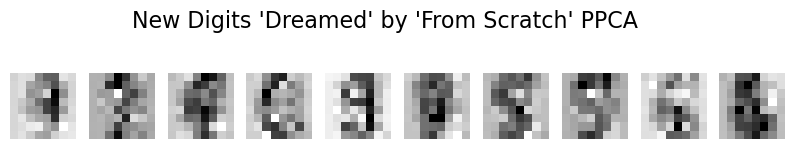


Fitting a 2-component model for visualization...
Transforming data to 2D...


C:\Users\jesli\AppData\Local\Temp\ipykernel_15460\570573676.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("jet", len(labels))


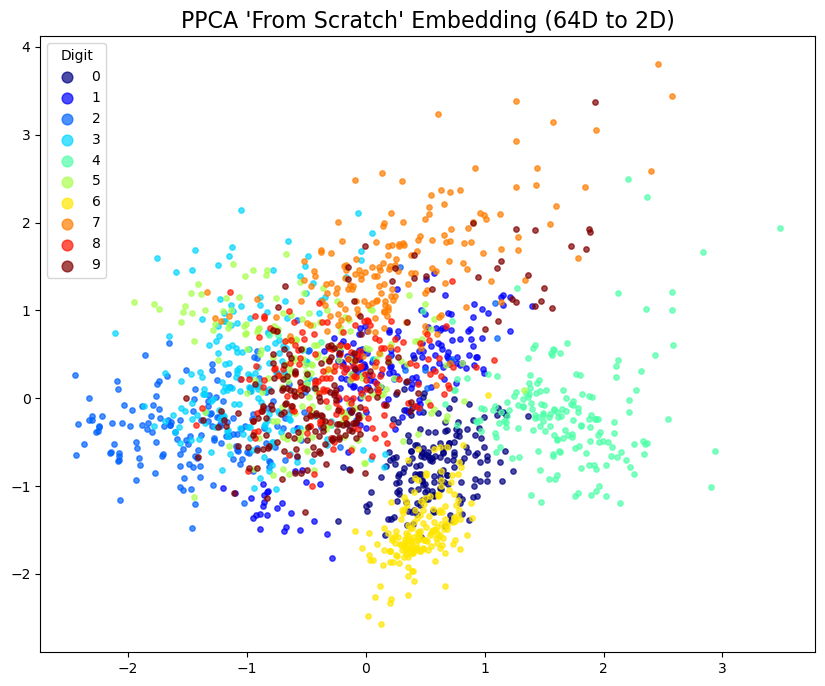

In [5]:
# --- Use Case 1: Generation ---
print("Fitting a 10-component model for generation...")
ppca_gen_model = PPCA_from_scratch(n_components=10)
ppca_gen_model.fit(X_scaled)

print("Generating new 'dreamed' digits...")
# Generate 10 new samples
generated_scaled = ppca_gen_model.sample(n_samples=10)

# IMPORTANT: We must "un-scale" the data to plot it
generated_unscaled = scaler.inverse_transform(generated_scaled)
plot_digits(generated_unscaled, "New Digits 'Dreamed' by 'From Scratch' PPCA")


# --- Use Case 2: Reduction ---
print("\nFitting a 2-component model for visualization...")
ppca_2d_model = PPCA_from_scratch(n_components=2)
ppca_2d_model.fit(X_scaled)

print("Transforming data to 2D...")
# Transform the *scaled* data
X_ppca_2D = ppca_2d_model.transform(X_scaled)

plot_embedding(X_ppca_2D, y, "PPCA 'From Scratch' Embedding (64D to 2D)")

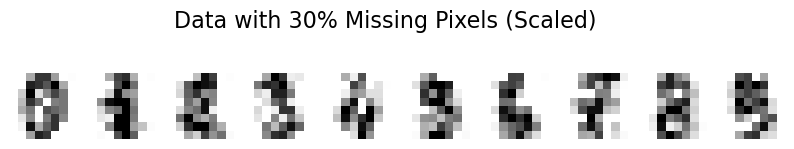

Starting EM imputation loop...
Imputation Iteration 5/15 complete.
Imputation Iteration 10/15 complete.
Imputation Iteration 15/15 complete.
Imputation finished.


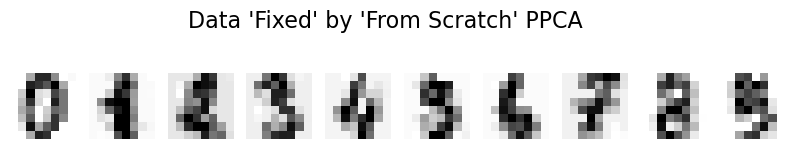

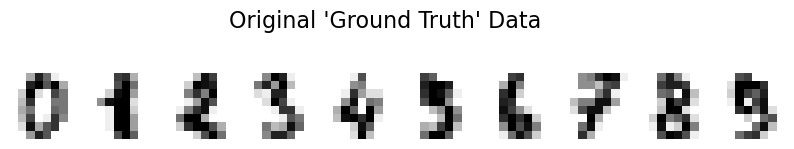

In [6]:
# 1. Create the "broken" data (using the SCALED data)
X_missing = X_scaled.copy()
missing_fraction = 0.3
mask = np.random.rand(n_samples, n_features) < missing_fraction
X_missing[mask] = np.nan

# 2. Make an initial guess (fill missing with 0)
# (0 is the mean of our scaled data, so this is a good guess)
X_imputed = np.nan_to_num(X_missing, nan=0.0)

# 3. Plot the broken data (we have to un-scale it first)
plot_digits(scaler.inverse_transform(X_imputed), "Data with 30% Missing Pixels (Scaled)")

print("Starting EM imputation loop...")
n_iters = 15
for i in range(n_iters):
    # E-Step: Project the current guess into latent space
    latent_scores = ppca_gen_model.transform(X_imputed)
    
    # M-Step: Reconstruct from latent space
    X_recon = ppca_gen_model.inverse_transform(latent_scores)
    
    # Update Step: Fill *only* the missing spots with the new values
    X_imputed[mask] = X_recon[mask]
    
    if (i+1) % 5 == 0:
        print(f"Imputation Iteration {i+1}/{n_iters} complete.")

print("Imputation finished.")

# 4. Un-scale the final, fixed data
X_fixed_unscaled = scaler.inverse_transform(X_imputed)

# 5. Plot the final result!
plot_digits(X_fixed_unscaled, "Data 'Fixed' by 'From Scratch' PPCA")
plot_digits(X_full, "Original 'Ground Truth' Data")